# Labor Risk Profiling: Predicting Income Inequality

## 1. Introduction & Data Loading
The goal of this project is to build a machine learning classification model capable of predicting whether an individual's income exceeds $50K/year based on census data. We will utilize first a Random Forest Classifier and deeply analyze the model's decision-making process using advanced interpretability techniques (SHAP, PDP, Permutation Importance). Then we'll compare it with Xgboost, clustering and deep learning algorithm.

First, we import the necessary libraries and load the dataset.
The dataset has been taken from
https://www.kaggle.com/datasets/sagnikpatra/uci-adult-census-data-dataset



In [105]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

In [106]:
import warnings
warnings.filterwarnings('ignore')

In [107]:
input_file = 'labor_risk_profiling_dataset\\adult.csv'
df=pd.read_csv(input_file)


## 2. Exploratory Data Analysis (EDA)
Before training the model, it is crucial to understand the underlying distribution of our data. In this section, we will:
* Check for missing values and handle them.
* Analyze the distribution of the target variable (`>50K` vs `<=50K`) to check for class imbalance.
* Visualize the relationships between key numerical/categorical features and the target variable.

In [108]:
df_1=df.copy()

In [109]:
df_1=df_1.replace('?', np.nan, inplace=True)

In [110]:
# df_1.isnull().sum()

In [111]:
# df_1.shape

### Missing analysis with matrix

<Axes: >

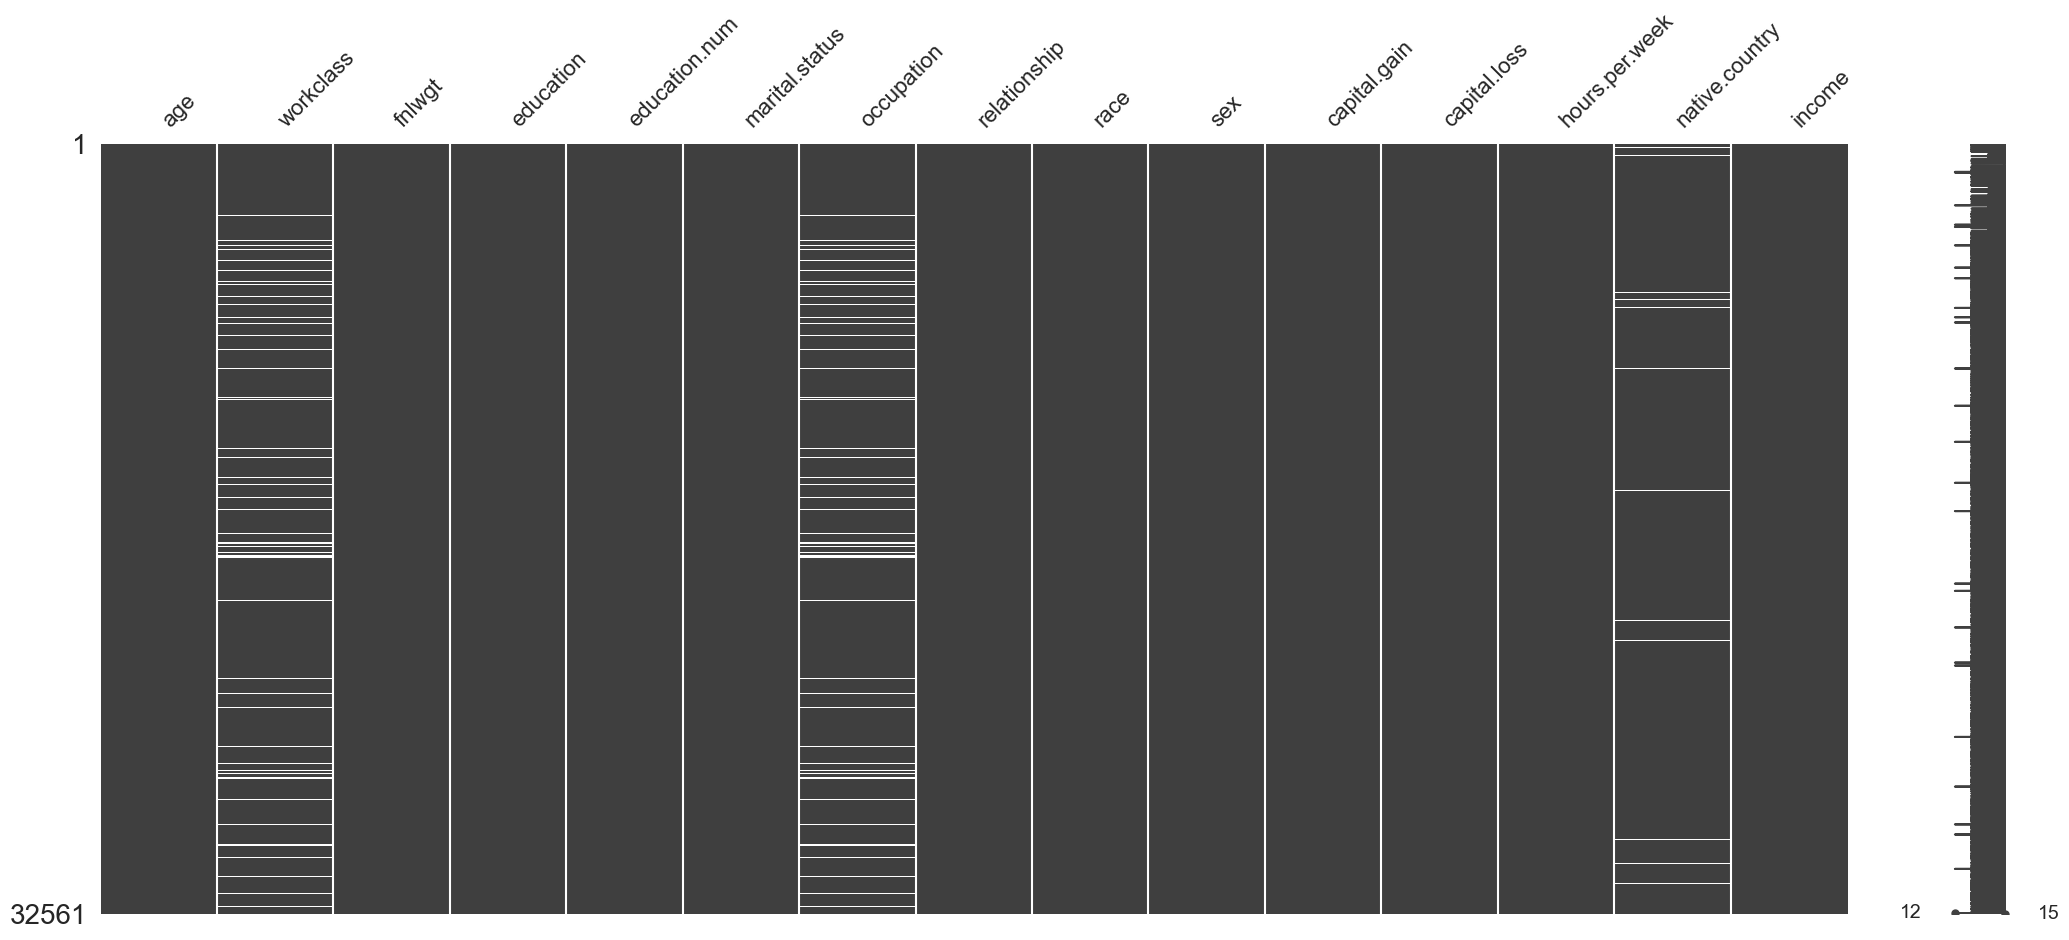

In [112]:
import missingno as msno
msno.matrix(df_1)

As shown in the missing data matrix, there is a perfect overlap in the missing values for workclass and occupation. This structural missingness suggests that when an individual's employment status is unknown or unrecorded, both their work sector and specific profession are naturally omitted.

### Bivariate Analysis: Exploring Working Hours

In this series of visualizations, we explore how various demographic and educational features correlate with the number of hours worked per week (`hours.per.week`). 

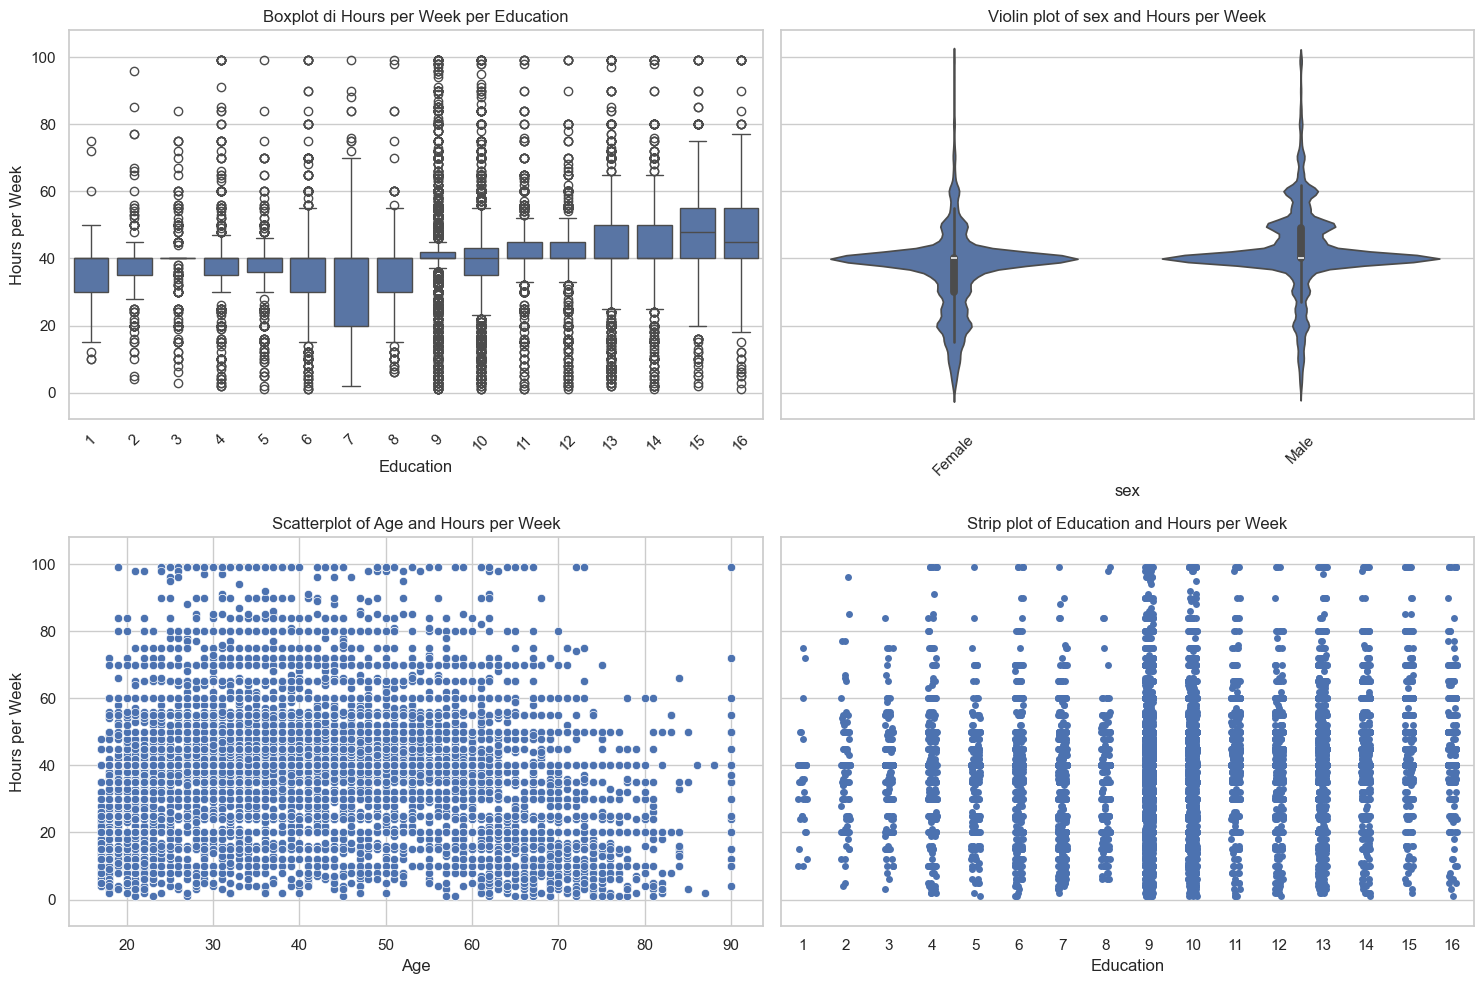

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

fig,axes=plt.subplots(2,2,figsize=(15,10), sharey=True)

#primo grafico
sns.boxplot(x='education.num', y='hours.per.week',data=df_1, ax=axes[0,0])
axes[0,0].set_title('Boxplot di Hours per Week per Education')
axes[0,0].set_xlabel('Education')
axes[0,0].set_ylabel('Hours per Week')
axes[0,0].tick_params(axis='x', rotation=45)

#secondo grafico
sns.violinplot(x='sex', y='hours.per.week',data=df_1, ax=axes[0,1])
axes[0,1].set_title('Violin plot of sex and Hours per Week')
axes[0,1].set_xlabel('sex')
axes[0,1].set_ylabel('Hours per Week')
axes[0,1].tick_params(axis='x', rotation=45)

#terzo grafico
sns.scatterplot(x='age', y='hours.per.week',data=df_1, ax=axes[1,0])
axes[1,0].set_title('Scatterplot of Age and Hours per Week')    
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Hours per Week')

#quarto grafico
sns.stripplot(x='education.num', y='hours.per.week',data=df_1, jitter=True, ax=axes[1,1])
axes[1,1].set_title('Strip plot of Education and Hours per Week')
axes[1,1].set_xlabel('Education')
axes[1,1].set_ylabel('Hours per Week')

plt.tight_layout()

### Income Probability by Age and Gender

In [114]:
# definizione delle fasce d'età
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['0-25', '26-35', '36-45', '46-55', '56-65', '66+']
df_1['age_bins'] = pd.cut(df_1['age'], bins=bins, labels=labels)
# Trasforma la colonna in categoria ordinata
df_1['age_bins'] = pd.Categorical(df_1['age_bins'], categories=labels, ordered=True)

In [115]:
df_1['is_high_income']=df_1['income'].apply( lambda x: 0 if x=='<=50K' else 1)

<Axes: xlabel='sex', ylabel='age_bins'>

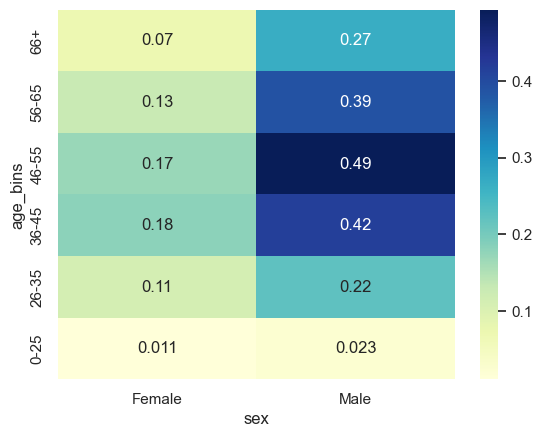

In [116]:
# mean number of people with income > 50K for sex and age_bins
pivot_income = df_1.pivot_table(values='is_high_income', index='age_bins', columns='sex', aggfunc='mean')
sns.heatmap(pivot_income.iloc[::-1], annot=True, cmap='YlGnBu')

This heatmap highlights the probability of an individual earning above the $50K income threshold, grouped by age bins and sex. 

The most evident takeaway from this visualization is the stark **gender inequality** regarding high-income possibilities. Across every single age bracket, men have a significantly higher probability of reaching the >$50K threshold compared to women. 

* **The Peak Earning Years:** The income gap becomes especially pronounced during the core career years (ages 40 to 60). In these age bins, the probability of high income for men peaks at **43-45%**, whereas for women in the exact same age groups, it never exceeds **18%**.

### High-Income Likelihood by Education Level and Sex

In [117]:
# pivot_education_income=pd.pivot_table(values='is_high_income', index='education.num', columns='sex', aggfunc='mean', data=df_1)

In [118]:
# sns.heatmap(pivot_education_income,annot=True)

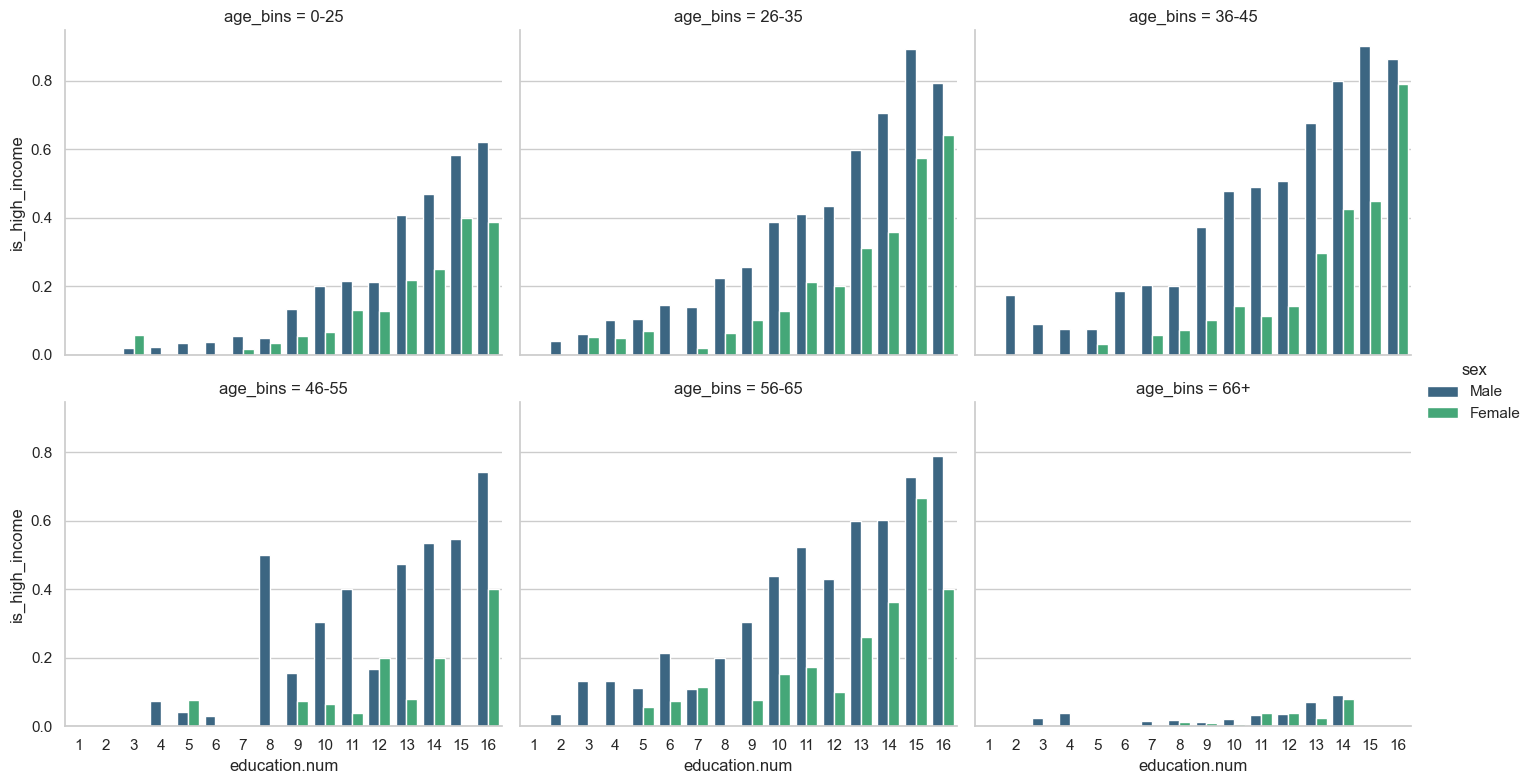

In [119]:
sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=df_1, 
    kind="bar",
    x="education.num", 
    y="is_high_income", 
    hue="sex",
    col="age_bins", 
    errorbar=None,
    col_wrap=3,          # Numero di grafici per riga
    palette="viridis",    # Schema colori
    height=4, 
    aspect=1.2
)

This faceted catplot illustrates the probability of high income across various age cohorts, segmented by gender and education level. The data demonstrates a persistent gender disparity that evolves over time; while the 'income gap' is present in younger years, it becomes drastically more pronounced during peak earning years (ages 36–65). Even at the highest levels of education, women consistently face a lower probability of high-income attainment than their male counterparts in every age bin

### Exploratory Plot: Assessing Feature Distribution and Correlation

In [120]:
# individuo le variabili numeriche e categoriche
def identify_variable_types(df):
    numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
    return numeric_features, categorical_features

In [121]:
result=identify_variable_types(df_1)

In [122]:
import math

In [123]:
def plot_outliers(df, lista):
        # Calcoliamo quante righe servono per avere 3 colonne al massimo
    n_cols = 3
    n_rows = math.ceil(len(lista) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() # Lo rendiamo 1D per gestirlo facilmente

    for i, col in enumerate(lista):
        sns.boxplot(data=df, x=col, ax=axes[i], color='skyblue', fliersize=5)
        axes[i].set_title(f'Focus Outlier: {col}', fontsize=14)
        axes[i].grid(True, linestyle='--', alpha=0.6)

    # Nascondiamo i grafici vuoti se la lista non riempie l'ultima riga
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

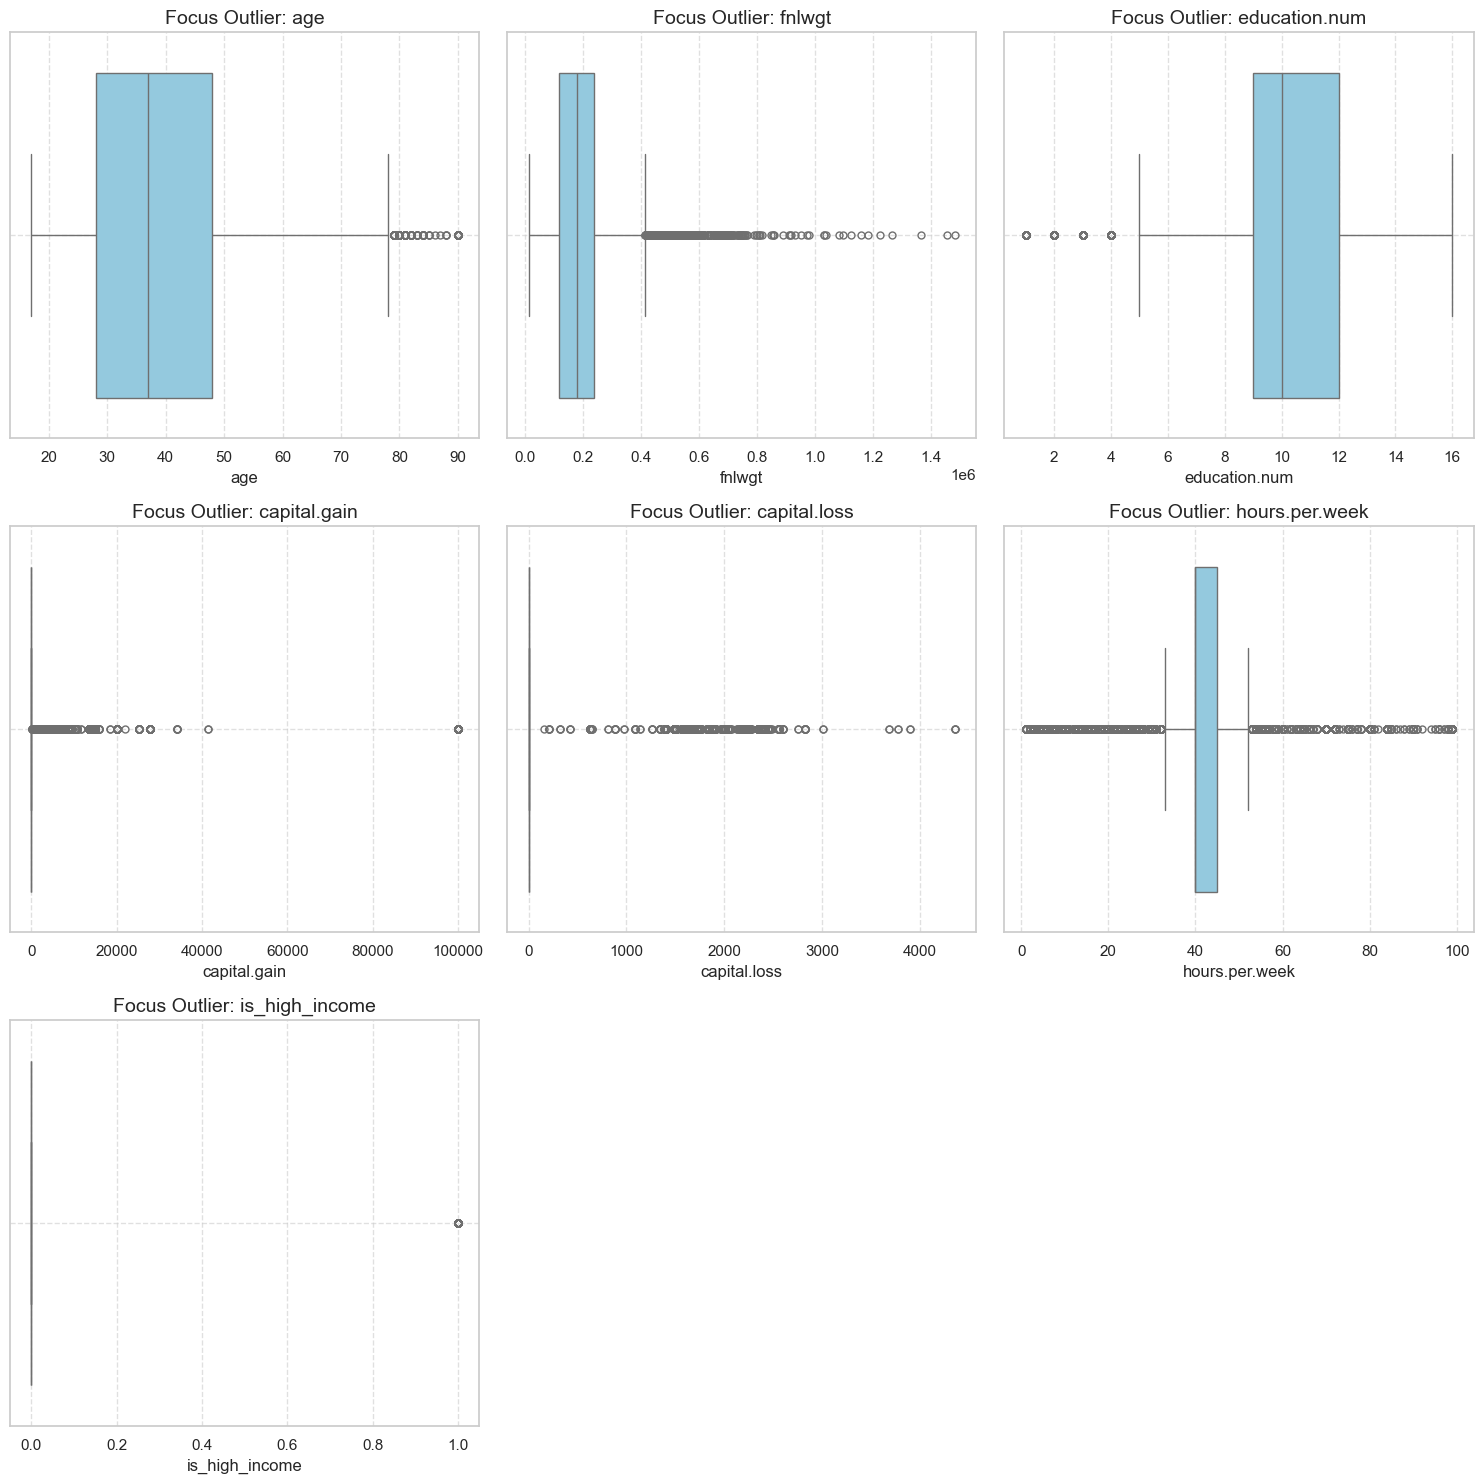

In [124]:
plot_outliers(df_1, result[0])

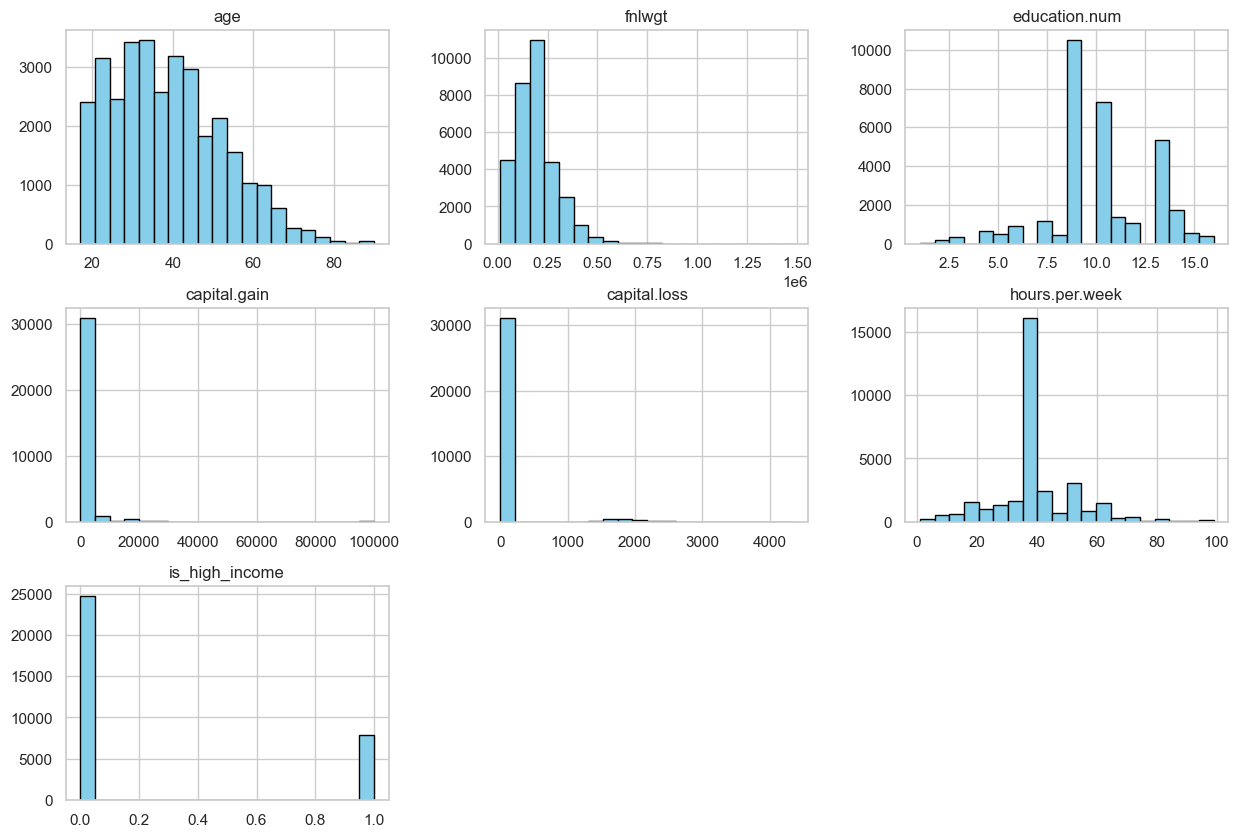

In [125]:
df_num=df_1.drop(columns=result[1])
ax=df_num.hist(figsize=(15,10), bins=20, color='skyblue', edgecolor='black')

In [126]:
df_1_sample=df_1[df_num.columns].sample(1000, random_state=42)

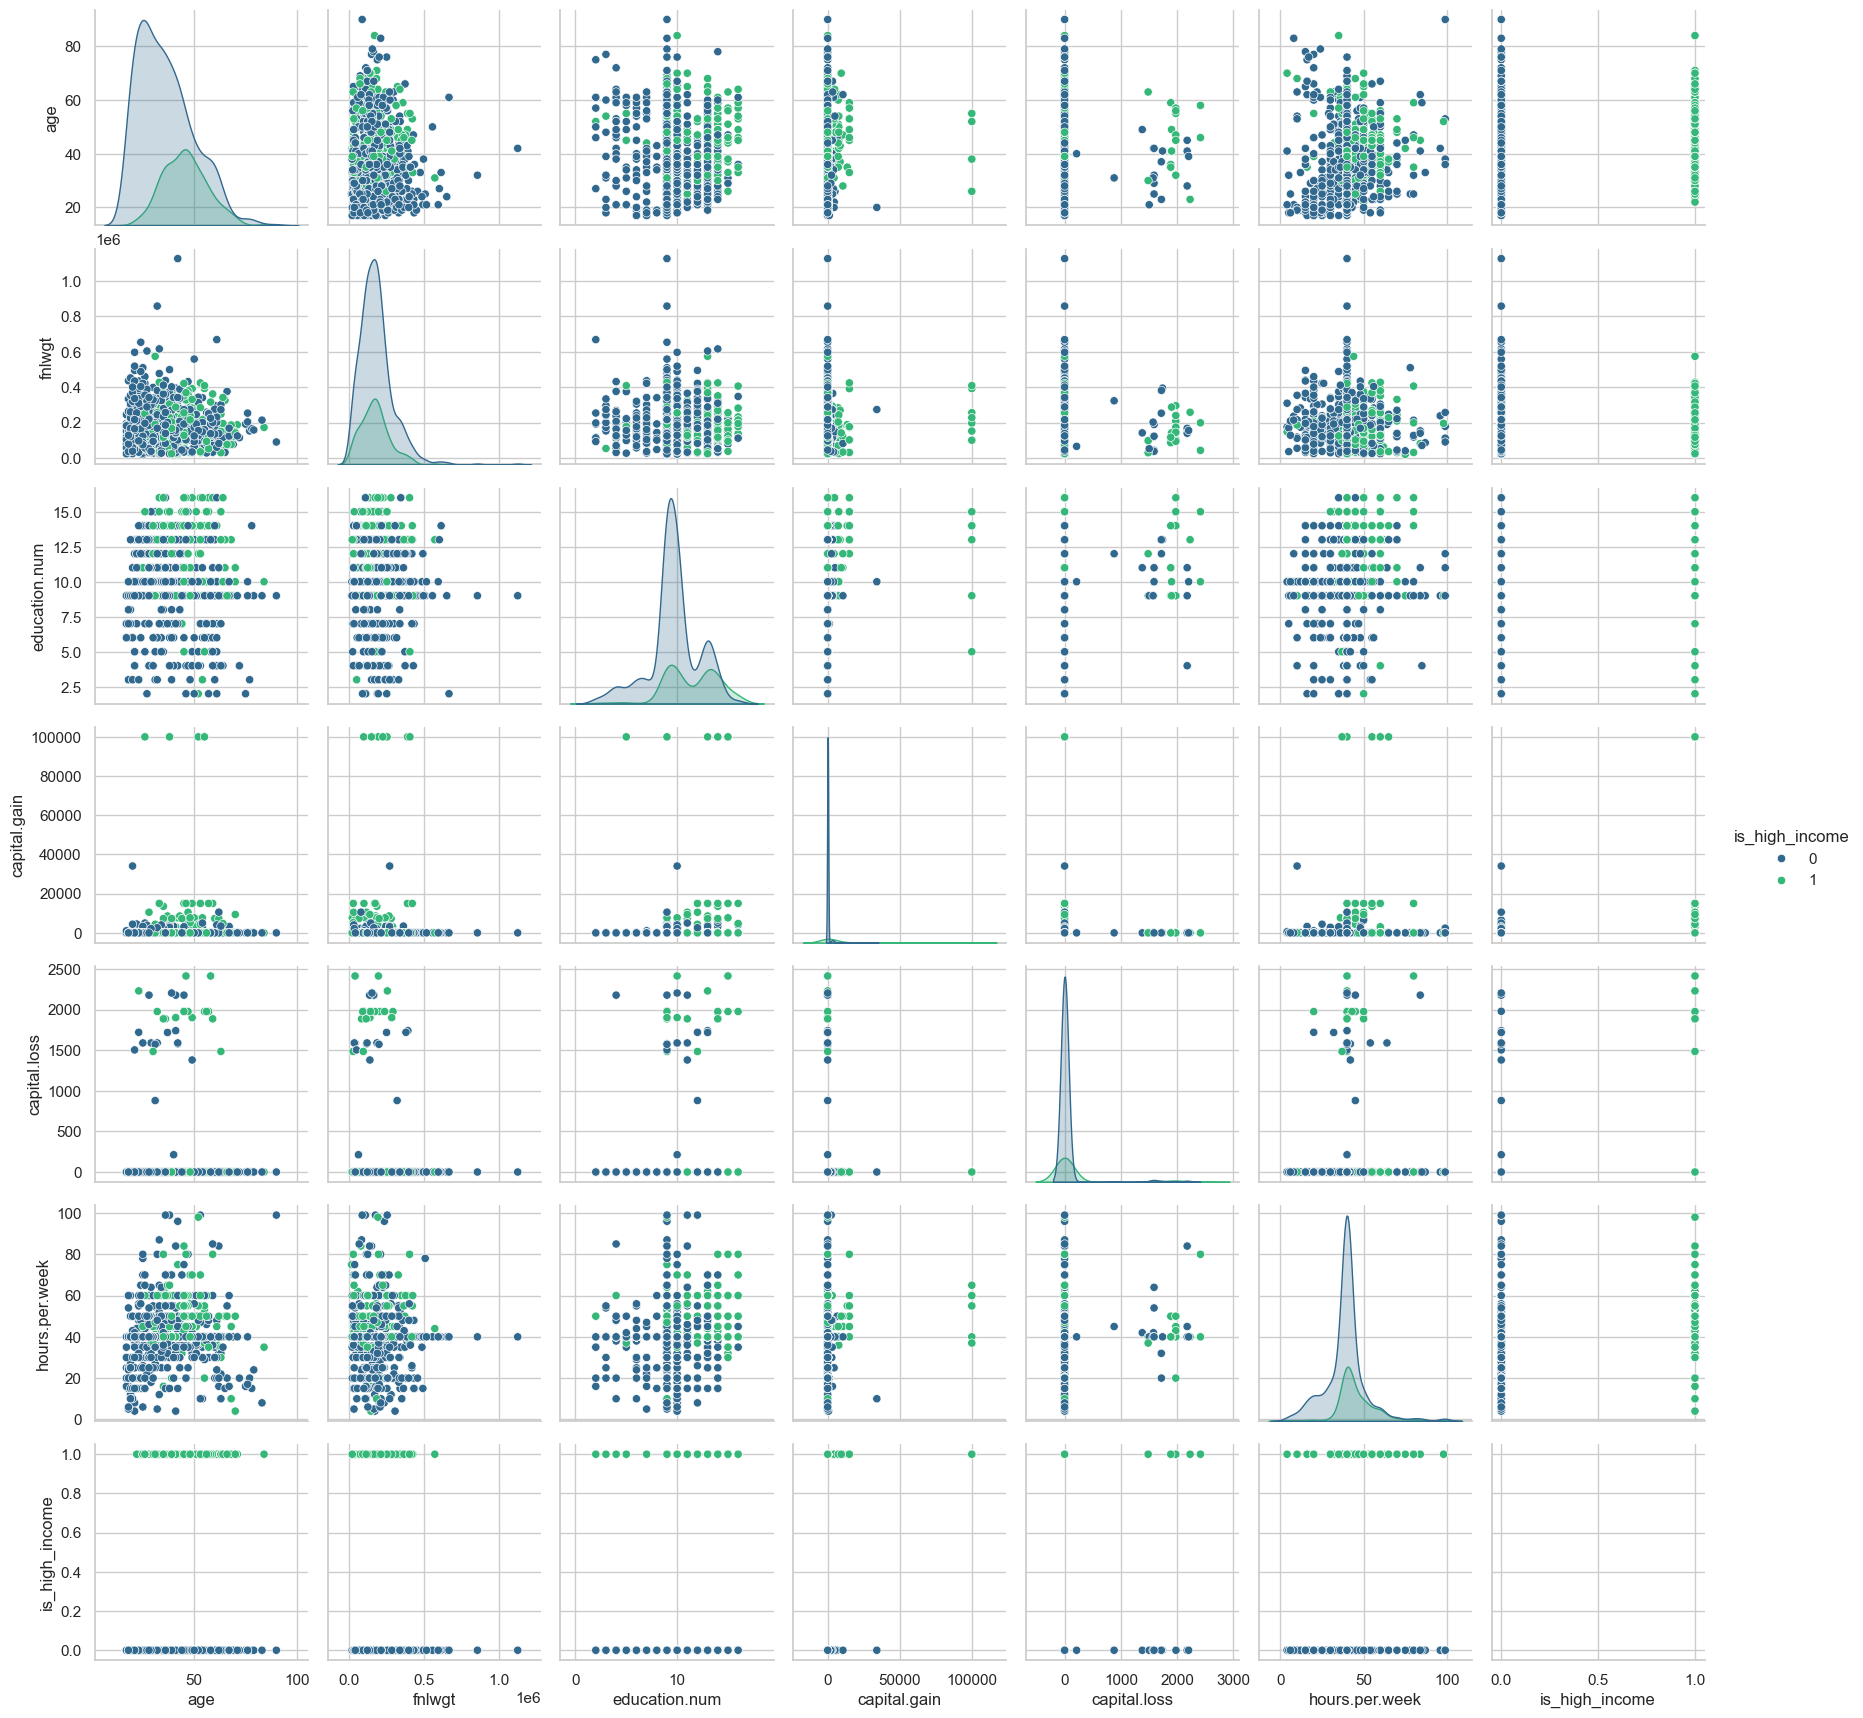

In [127]:
sns.pairplot(df_1_sample, vars=df_num.columns, hue='is_high_income', palette='viridis')

The presence of significant skewness and numerous outliers in variables like capital.gain and fnlwgt suggests that data scaling or normalization may be necessary before training a machine learning model. Additionally, the class imbalance in the target variable (is_high_income) should be addressed to avoid model bias.

### Spearman Correlation Matrix

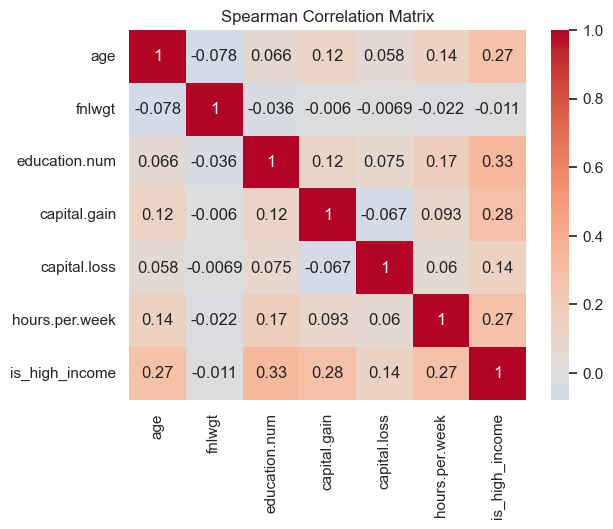

In [128]:
corr_spearman=df_1[result[0]].corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', center=0)
plt.title('Spearman Correlation Matrix')
plt.show()

The Spearman Correlation Matrix identifies education.num and capital.gain as the strongest predictors of the high-income target variable. While the coefficients indicate moderate positive correlations, they are significantly higher than other features. Additionally, age and hours.per.week show secondary levels of correlation, suggesting they are also relevant contributors to the model's predictive power.

### Contingency table

In [129]:
# Creiamo la tabella di contingenza grezza
contingency_table = pd.crosstab(df_1['race'], df_1['is_high_income'])

print("Contingency table (Absolute Frequencies):")
print(contingency_table)

Contingency table (Absolute Frequencies):
is_high_income          0     1
race                           
Amer-Indian-Eskimo    275    36
Asian-Pac-Islander    763   276
Black                2737   387
Other                 246    25
White               20699  7117


The contingency table illustrates the distribution of income levels across different ethnic groups. While the absolute number of high earners is highest within the 'White' group, a proportional analysis is required to account for the significant class imbalance. Preliminary observations suggest varying rates of high-income attainment across groups, which may indicate systemic economic disparities that warrant further statistical testing, such as a Chi-Square test.

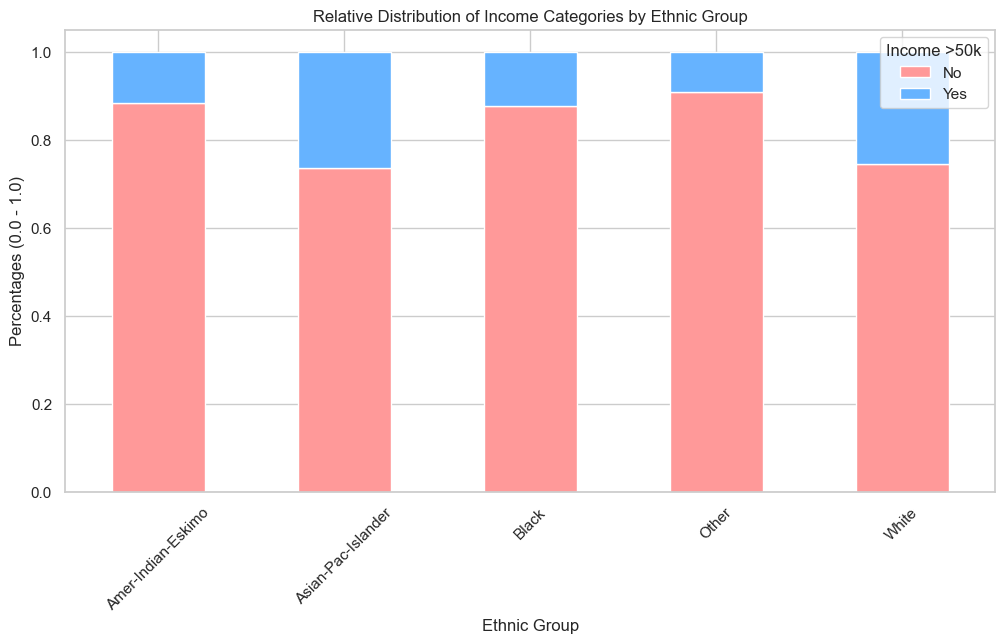

In [130]:
#trasformo in frequenze relative
# Normalizziamo per riga (ogni riga somma a 1.0, ovvero 100%)
ct_normalized = pd.crosstab(df_1['race'], df_1['is_high_income'], normalize='index')

# Creiamo lo Stacked Bar Chart
ct_normalized.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999', '#66b3ff'])
plt.title("Relative Distribution of Income Categories by Ethnic Group")
plt.ylabel("Percentages (0.0 - 1.0)")
plt.xlabel("Ethnic Group")
plt.legend(title="Income >50k", labels=["No", "Yes"])
plt.xticks(rotation=45)
plt.show()

The normalized stacked bar chart illustrates the proportional distribution of income categories within each ethnic group. By standardizing the data, we can observe that the 'Asian-Pac-Islander' and 'White' groups exhibit the highest relative frequencies of high-income attainment (blue). In contrast, the 'Other', 'Black', and 'Amer-Indian-Eskimo' groups show a significantly higher proportion of individuals in the lower-income bracket (red), highlighting a clear economic disparity that is independent of total group size.

In [131]:
# check statiscal significance with chi2 test
from scipy.stats import chi2_contingency

# Eseguiamo il test sulla tabella dei FATTI (quella non normalizzata dello Step 1)
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Statistic Chi-Square: {chi2:.2f}")
print(f"P-Value: {p:.4e}") # Notazione scientifica perché sarà molto piccolo

Statistic Chi-Square: 330.92
P-Value: 2.3060e-70


In [132]:
# cramer's V
n = contingency_table.sum().sum() # Totale campioni
min_dim = min(contingency_table.shape) - 1 # Minimo tra (righe-1) e (colonne-1)
v_cramer = np.sqrt(chi2 / (n * min_dim))

print(f"Cramer's V: {v_cramer:.4f}")

Cramer's V: 0.1008


Statistical tests confirm the existence of an economic disparity across ethnic groups. The extremely low p-value indicates that the relationship is statistically significant, while the Cramer's V (0.10) suggests that, although ethnicity influences income, the strength of this association is modest. This indicates that other socioeconomic factors contribute simultaneously to determining income levels.

In [133]:


def analyze_all_categorical(df, cat_columns, target_col):
    results = []

    for col in cat_columns:
        # 1. Tabella di contingenza
        ct = pd.crosstab(df[col], df[target_col])
        
        # 2. Test Chi-Quadro
        chi2, p, dof, expected = chi2_contingency(ct)
        
        # 3. Calcolo V di Cramer
        n = ct.sum().sum()
        min_dim = min(ct.shape) - 1
        v_cramer = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
        
        # Salviamo i risultati in un dizionario
        results.append({
            'Variable': col,
            'Chi-Square': round(chi2, 2),
            'P-Value': f"{p:.4e}",
            'Cramer\'s V': round(v_cramer, 4),
            'Significant': "Yes" if p < 0.05 else "No"
        })

    # Creiamo il DataFrame finale e ordiniamo per V di Cramer (più alta = più importante)
    summary_df = pd.DataFrame(results).sort_values(by='Cramer\'s V', ascending=False)
    return summary_df



In [136]:
# Esecuzione
tabella_risultati_cat = analyze_all_categorical(df_1, result[1], 'is_high_income')
tabella_risultati_cat

,Variable,Chi-Square,P-Value,Cramer's V,Significant
8,income,32555.53,0.0000e+00,0.9999,Yes
4,relationship,6699.08,0.0000e+00,0.4536,Yes
2,marital.status,6517.74,0.0000e+00,0.4474,Yes
1,education,4429.65,0.0000e+00,0.3688,Yes
3,occupation,3744.90,0.0000e+00,0.3492,Yes
9,age_bins,3217.53,0.0000e+00,0.3143,Yes
6,sex,1517.81,0.0000e+00,0.2159,Yes
0,workclass,827.72,1.9338e-174,0.1641,Yes
5,race,330.92,2.3060e-70,0.1008,Yes
7,native.country,317.09,8.2804e-45,0.0996,Yes


The summary table of Chi-Square and Cramer's V tests reveals that all analyzed variables are statistically significant (p-value $\approx$ 0). However, the strength of these associations varies considerably. Relationship and Marital Status exhibit the strongest associations with income (Cramer's V $\approx$ 0.45), followed closely by Education and Occupation. Conversely, variables such as Race and Native Country, while statistically significant, show the weakest practical association (Cramer's V $\approx$ 0.10). This suggests that while demographic factors play a role, household structure and human capital (education/job) are far more powerful predictors of high-income attainment.

In [ ]:
# Creiamo la tabella di contingenza grezza
con_marital_age = pd.crosstab(df_1['marital.status'], df_1['age_bins'])
print(f"Tabella di contingenza:\n {con_marital_age}")

Tabella di contingenza:
 age_bins               0-25  26-35  36-45  46-55  56-65  66+
marital.status                                              
Divorced                129    988   1630   1126    471   99
Married-AF-spouse         4     14      3      1      0    1
Married-civ-spouse      675   3759   4580   3459   1862  641
Married-spouse-absent    48    115    110     96     34   15
Never-married          5456   3290   1241    441    175   80
Separated                95    313    338    196     69   14
Widowed                   4     35    107    219    320  308


In [ ]:
#trasformo in frequenze relative
# Normalizziamo per riga (ogni riga somma a 1.0, ovvero 100%)
ct_norm_marital_age = pd.crosstab(df_1['marital.status'], df_1['age_bins'], normalize='index')
ct_norm_marital_age

age_bins,0-25,26-35,36-45,46-55,56-65,66+
marital.status,,,,,,
Divorced,0.029034,0.222372,0.366869,0.253432,0.106009,0.022282
Married-AF-spouse,0.173913,0.608696,0.130435,0.043478,0.000000,0.043478
Married-civ-spouse,0.045072,0.251002,0.305823,0.230970,0.124332,0.042802
Married-spouse-absent,0.114833,0.275120,0.263158,0.229665,0.081340,0.035885
Never-married,0.510718,0.307966,0.116166,0.041281,0.016381,0.007489
Separated,0.092683,0.305366,0.329756,0.191220,0.067317,0.013659
Widowed,0.004028,0.035247,0.107754,0.220544,0.322256,0.310171


<Axes: xlabel='marital.status'>

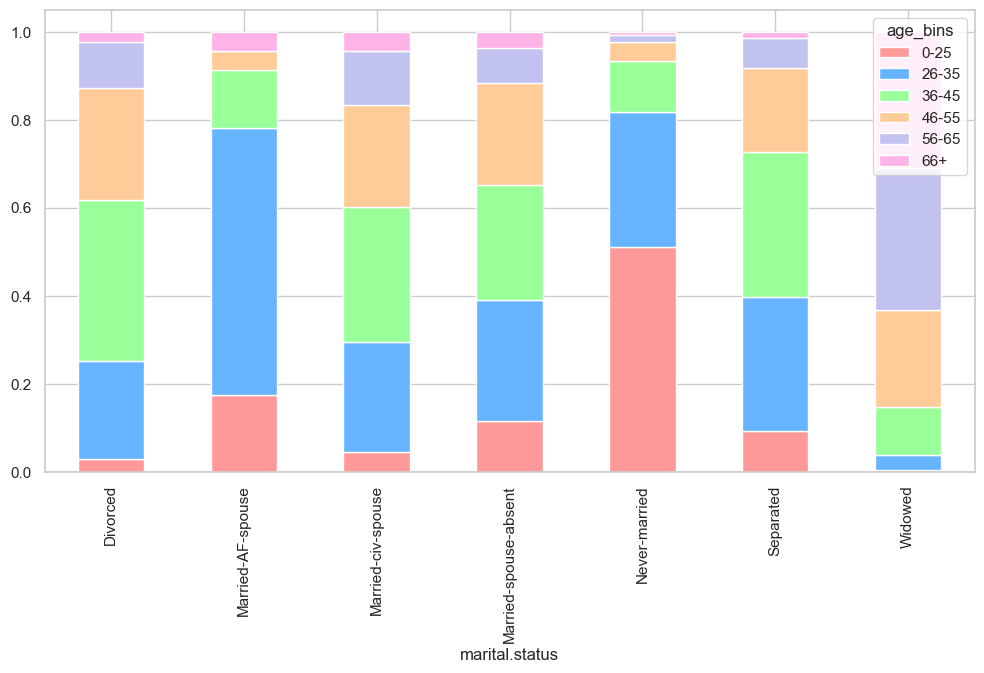

In [ ]:
ct_norm_marital_age.plot(kind='bar',stacked=True, figsize=(12, 6), color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6'])

In [ ]:

chi2, p, dof, expected = chi2_contingency(con_marital_age)
print(f"Statistica Chi-Quadro: {chi2:.2f}")
print(f"P-Value: {p:.4e}")
print(f"grado di libertà: {dof}")

Statistica Chi-Quadro: 15080.61
P-Value: 0.0000e+00
grado di libertà: 30


In [ ]:
# cramer's V
n = con_marital_age.sum().sum() # Totale campioni
n

np.int64(32561)

In [ ]:
min_dim = min(con_marital_age.shape) - 1 # Minimo tra (righe-1) e (colonne-1)
v_cramer = np.sqrt(chi2 / (n * min_dim))

print(f"V di Cramer: {v_cramer:.4f}")

V di Cramer: 0.3044


Il collegamento con la tua EDA
Il ColumnTransformer è dove metti in pratica i tuoi risultati:

Hai visto V di Cramer 0.30 tra marital-status e age? Ecco perché nel codice sopra le ho tenute entrambe.

Hai visto che capital-gain è schiacciato nei boxplot? Usi RobustScaler invece di StandardScaler.

Hai visto che income ha V di Cramer 0.99? Lo lasci fuori dal trasformatore (o usi remainder='drop').

## 3. Data Preprocessing & Pipeline Construction
Machine learning models require numerical input. Here, we build a Scikit-Learn `Pipeline` to handle data transformations automatically and prevent data leakage:
* **Numerical Features:** Imputing missing values and scaling.
* **Categorical Features:** Applying One-Hot Encoding to transform text labels into a machine-readable format.

In [ ]:
# Identifichiamo i paesi rari (meno di 100 occorrenze)
counts = df_1['native.country'].value_counts()
rare_countries = counts[counts < 100].index


In [ ]:
# Li sostituiamo con 'Other'
df_1['native.country'] = df_1['native.country'].replace(rare_countries, 'Other')

### Data Preparation: Feature and Target Separation
Separate the dataset into the Features ($X$) and the Target ($y$) to prepare for supervised learning

In [ ]:
X=df_1.drop(columns=['income', 'is_high_income'])
y=df_1['is_high_income']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# Dividiamo subito in Train e Test (fondamentale per evitare Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### ColumnTransformer Definition

Using ColumnTransformer to apply specific preprocessing pipelines to each feature type:

- Numerical Features: Applied RobustScaler to handle the high volume of outliers detected during EDA.
- Categorical Features: Applied OneHotEncoder to convert qualitative categories into a machine-readable format.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline

In [ ]:
#identificazione colonne numeriche e categoriche
num_features=[x for x in result[0] if x not in ['is_high_income', 'fnlwgt']]


In [ ]:
cat_features=[x for x in result[1] if x not in ['income','age_bins']]


### Preprocessor

In [ ]:
# Creiamo il preprocessore
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
    ]
)

### Full Pipeline (Preprocessing + Model)
We consolidate the preprocessor and a Random Forest Classifier into a single Pipeline object.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Creiamo la pipeline finale
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

# Alleniamo tutto il blocco in una riga sola!
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

### Random forest results

In [ ]:
from sklearn.metrics import classification_report

y_pred = model_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      4945
           1       0.68      0.63      0.65      1568

    accuracy                           0.84      6513
   macro avg       0.78      0.77      0.77      6513
weighted avg       0.83      0.84      0.84      6513



#### Model Performance Analysis
The results are solid for an initial run on the Adult dataset. An 84% accuracy is standard, but the real insights lie in the class-specific metrics:
- **Majority Class** ($\le$50k): High performance (88% Precision / 91% Recall). The model is excellent at identifying low-to-mid earners because they represent the majority of the data.
- **Minority Class** (>50k): Performance drops (0.68 Precision / 0.63 Recall). The model struggles to isolate the specific signals of high earners, missing about 37% of them (Recall) and occasionally misidentifying low earners as "rich" (Precision).
- **Generalization**: The 84% accuracy suggests the model is generalising well. By grouping native-country during preprocessing, you prevented overfitting, ensuring the model learned meaningful patterns rather than memorizing noise from rare categories.
 
**Conclusion**: The model is honest and stable, though it remains slightly biased toward the majority class—a common challenge in imbalanced datasets.

#### Hyperparameter Tuning: Grid Search
We use Grid Search to find the optimal configuration for the Random Forest:

- Objective: Systematically test combinations of parameters (like n_estimators and max_depth).

- Method: Employs Cross-Validation to ensure the best parameters are consistent across different data folds.

- Goal: Maximize predictive performance and reduce bias toward the majority class.

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
#definiamo i parametri da testare
param_grid = {
    'classifier__n_estimators': [100],
    'classifier__max_depth': [None, 10],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__class_weight': ['balanced']
}


We tune the following parameters to optimize the bias-variance tradeoff and handle class imbalance:

- n_estimators [100, 200]: Number of trees. More trees increase stability but also computation time.

- max_depth [None, 10, 20]: Maximum tree depth. Limiting depth prevents trees from becoming overly complex and overfitting.

- min_samples_split [2, 5]: Minimum samples required to split a node. Higher values lead to more conservative trees.

- min_samples_leaf [1, 2]: Minimum samples per leaf. Increasing this value smooths the model, especially in noisy data. Higher values ensure every conclusion the tree draws is backed by enough evidence, making it less sensitive to noise.

- class_weight ['balanced', 'balanced_subsample']: Adjusts weights inversely proportional to class frequencies to give more importance to the minority class (high income).

In [ ]:
# Definiamo una griglia di iperparametri da testare
from sklearn.model_selection import RandomizedSearchCV


random_search = RandomizedSearchCV(
    model_pipeline,
    param_grid,
    n_iter=12,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

# ho ridotto a cv 3  
# scelto randomized al posto di grid Invece di provare tutte le 48 combinazioni, ne campiona un numero fisso a caso  
# tolto dai parametri alcuni settaggi per ridurre i tempi

In [ ]:

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__class_weight': ['balanced'], 'classifier__max_depth': [None, 10], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation stra

In [ ]:
# best_model e best_params sono attributi che grid e random popolano automaticamente

print(f"Best parameters found: {random_search.best_params_}")
best_model = random_search.best_estimator_

Migliori parametri trovati: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': None, 'classifier__class_weight': 'balanced'}


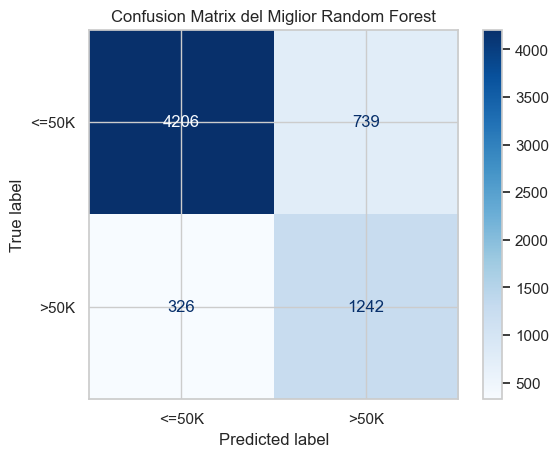

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predizione con il miglior modello
y_pred = best_model.predict(X_test)

# Generazione della matrice
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix of the Best Random Forest")
plt.show()

- True Negatives (4206): The model correctly identified almost everyone earning ≤$50K. It is very reliable on the majority class.
- True Positives (1242): The model correctly flagged most high-income individuals — a strong result given how underrepresented this class is in the data.
- False Negatives (326): These are the "missed rich" — people the model predicted as low-income when they actually earn >$50K. This number being low means the model has strong Recall: it rarely lets a true positive slip through.
- False Positives (739): These are the "false alarms" — people predicted as high-income who actually earn ≤$50K. This is the main weakness of the model.

Technical note: Using class_weight='balanced' makes the model more aggressive in hunting for high-income cases. This is a deliberate tradeoff: the model accepts more False Positives in exchange for fewer False Negatives — in other words, it would rather over-predict rich than miss them entirely. Whether this tradeoff is acceptable depends on the cost of each type of error in your specific use case.

#### Global interpretation

##### Permutation Importance
 Ti permette di mostrare subito una classifica delle feature più importanti per il tuo Random Forest su tutto il dataset.

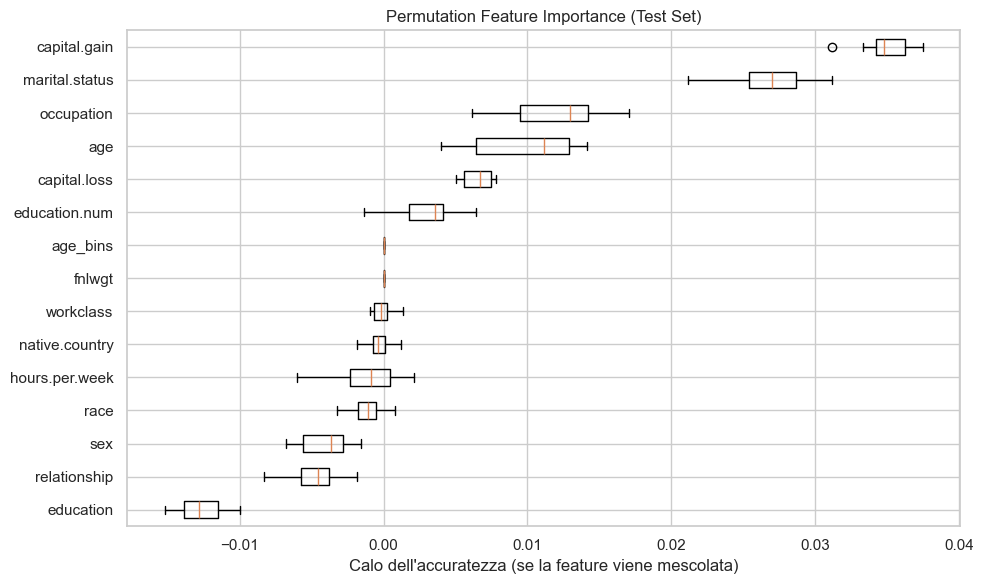

In [ ]:

from sklearn.inspection import permutation_importance

# 1. Calcolo della Permutation Importance
# n_repeats=10 significa che mescola ogni colonna 10 volte per avere una stima robusta
result = permutation_importance(
    estimator=model_pipeline, 
    X=X_test, 
    y=y_test, 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1 # Usa tutti i core del processore per velocizzare
)

# 2. Ordinamento delle feature dalla meno importante alla più importante
sorted_idx = result.importances_mean.argsort()

# 3. Creazione del grafico (Boxplot)
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    result.importances[sorted_idx].T,
    vert=False,
    labels=X_test.columns[sorted_idx]
)
ax.set_title("Permutation Feature Importance (Test Set)")
ax.set_xlabel("Calo dell'accuratezza (se la feature viene mescolata)")
fig.tight_layout()
plt.show()

1. L'Asse X: Il "Calo di Performance"
L'asse orizzontale misura di quanto peggiora il modello (ad esempio la sua Accuratezza o il suo F1-Score) quando prendiamo i dati di una specifica colonna e li mescoliamo a caso, distruggendo la loro relazione originaria con il target.

Valori alti (verso destra): Significa che mescolando quella colonna il modello è andato in crisi profonda. Dunque, quella feature è fondamentale.

Valori bassi (vicino allo 0): Significa che il modello ha continuato a prevedere bene anche con la colonna mescolata. Dunque, quella feature è inutile o ridondante.

Valori negativi (meno di 0): A volte capita! Significa che mescolando la colonna il modello è addirittura migliorato. Questo indica che quella variabile introduce solo "rumore" e confonde l'algoritmo (potresti persino valutare di rimuoverla).

2. L'Asse Y: La Classifica
Le feature sono solitamente ordinate dalla più importante (in cima) alla meno importante (in fondo). È letteralmente la classifica di ciò che il tuo Random Forest "guarda di più" prima di prendere una decisione.

3. I "Box" o le Linee
Se vedi dei rettangolini (boxplot) o delle linee di errore, è perché il codice ha ripetuto il rimescolamento più volte (es. 10 volte) per essere sicuro che il risultato non fosse frutto del caso. Un rettangolo molto largo indica molta incertezza sull'importanza di quella feature, un rettangolo stretto indica che l'impatto è sempre quello, rimescolamento dopo rimescolamento.

#### Partial Dependence Plots (PDP)
Una volta che il grafico precedente ti ha svelato quali sono le feature più importanti, prendi i nomi delle prime 2 o 3 e inseriscili nei PDP per vedere come influenzano la predizione.

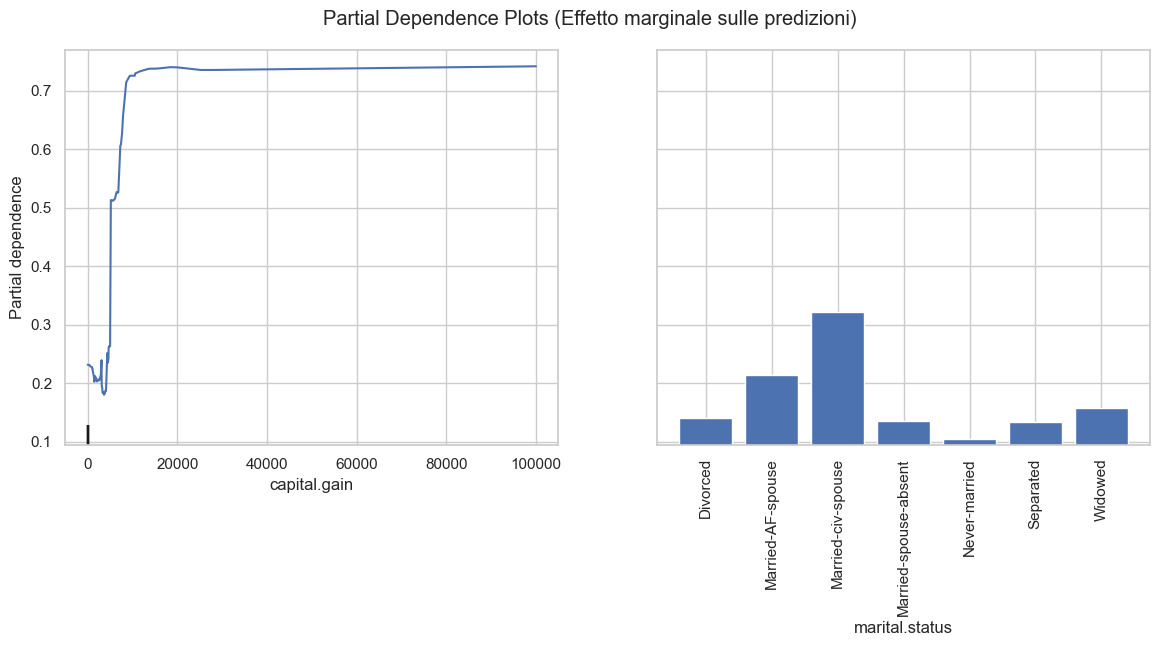

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

features_to_plot = ['capital.gain', 'marital.status']

# Creazione della figura
fig, ax = plt.subplots(figsize=(14, 5)) # Ho allargato un po' la figura per il testo

# Generazione del PDP
display = PartialDependenceDisplay.from_estimator(
    estimator=model_pipeline,
    X=X_test,
    features=features_to_plot,
    categorical_features=['marital.status'], # <--- ECCO LA MAGIA: Avvisiamo che è testo!
    kind="average", 
    ax=ax
)

display.figure_.suptitle("Partial Dependence Plots (Effetto marginale sulle predizioni)")
display.figure_.subplots_adjust(top=0.9)
plt.show()

Capital Gain (Guadagni in conto capitale)
Cosa si vede: La linea è completamente piatta per quasi tutta la prima metà del grafico, e poi fa un "salto" improvviso (uno scalino) verso l'alto superata la soglia dei 40.000 - 50.000.

Come si spiega: Il modello ci sta dicendo che avere un capital.gain basso (o pari a zero, come accade per la stragrande maggioranza delle persone) non influisce minimamente sulla probabilità di guadagnare >50K. Tuttavia, c'è un effetto soglia: se una persona registra un guadagno in conto capitale altissimo (superiore a 40k-50k), il modello fa schizzare in alto la probabilità di assegnarla alla Classe 1. È una variabile "grilletto": scatta solo per i valori estremi.

2. Marital Status (Stato Civile)
Cosa si vede: Qui il divario è netto. Le barre di Married-civ-spouse (sposati con un civile) e Married-AF-spouse (sposati con un militare) sono altissime, mentre tutte le altre (Never-married, Divorced, Widowed, ecc.) sono rasoterra.

Come si spiega: Questa è una delle associazioni più forti che il modello ha imparato. Essere sposati aumenta drasticamente la probabilità che il modello preveda un reddito >50K. Al contrario, essere single, divorziati o vedovi tiene la predizione verso il basso (Classe 0). Nota di dominio: questo ha molto senso demografico nel dataset, perché le persone sposate tendono a essere più in là con l'età e in una fase lavorativa più avanzata e stabile rispetto a chi non si è mai sposato.

#### Interpretabilità Locale (Analisi di casi specifici)

6.1 SHAP: Qui inserisci il lavoro che hai già fatto. Prendi 1 o 2 persone (magari un caso classificato come 0 e uno come 1) e mostra i valori SHAP per spiegare la decisione.

6.2 LIME: (Opzionale). Puoi inserirlo subito sotto SHAP. Puoi spiegare la stessa persona usata per SHAP e far vedere come LIME giunga a conclusioni simili (o diverse!).

### ROC CURVE random forest

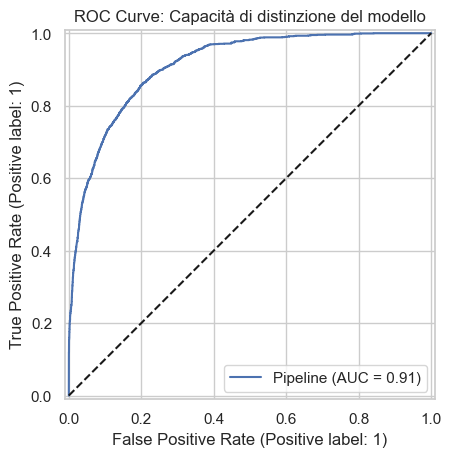

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.plot([0, 1], [0, 1], 'k--') # Linea del caso (modello inutile)
plt.title("ROC Curve: Capacità di distinzione del modello")
plt.show()



2. ROC Curve e AUC (Potere di distinzione area under the curve)
La curva ROC rappresenta il trade-off tra la sensibilità (beccare i ricchi) e la specificità (non scambiare i poveri per ricchi).

AUC = 0.91: L'Area Under the Curve misura la capacità del modello di separare le due classi. 0.5 è un lancio di moneta, 1.0 è la perfezione. 0.91 significa che nel 91% dei casi, se prendi una persona a caso del gruppo >50K e una del gruppo ≤50K, il modello darà un punteggio più alto alla prima.

La forma della curva: La curva sale molto velocemente verso l'alto a sinistra. Significa che il modello riesce a identificare una grande fetta di redditi alti mantenendo bassissimi i falsi allarmi nelle prime fasi della classificazione.

Curva ROC — esempio pratico
Immagina un modello che deve classificare 10 pazienti come malati (1) o sani (0).
Il modello non restituisce solo 0/1, ma una probabilità:
Paziente  | Prob. malato | Realtà
----------|--------------|-------
A         | 0.95         | 1  ✓
B         | 0.88         | 1  ✓
C         | 0.75         | 0  ✗
D         | 0.60         | 1  ✓
E         | 0.55         | 0  ✗
F         | 0.40         | 1  ✓
G         | 0.35         | 0  ✓
H         | 0.20         | 0  ✓
I         | 0.10         | 1  ✗
L         | 0.05         | 0  ✓

Come si costruisce
Sposti una soglia da 1.0 a 0.0. Ad ogni soglia calcoli:

TPR (Recall) → dei veri malati, quanti hai trovato?
FPR → dei veri sani, quanti hai classificato erroneamente come malati?

Soglia 0.90 → TPR=0.20, FPR=0.00  (molto severo, pochi positivi)
Soglia 0.60 → TPR=0.60, FPR=0.25
Soglia 0.40 → TPR=0.80, FPR=0.50
Soglia 0.10 → TPR=1.00, FPR=1.00  (molto permissivo, tutti positivi)
Ogni riga è un punto sulla curva ROC.

Il grafico
  ::view-transition-group(*),
  ::view-transition-old(*),
  ::view-transition-new(*) {
    animation-duration: 0.25s;
    animation-timing-function: cubic-bezier(0.19, 1, 0.22, 1);
  }
VvisualizeVvisualize show_widget
Come leggere il grafico
Ogni punto blu è una soglia diversa. Spostandosi da destra a sinistra stai alzando la soglia (diventi più selettivo).

Angolo in alto a sinistra → modello perfetto: tutti i malati trovati, zero falsi allarmi
Diagonale grigia → modello inutile: equivale a tirare a caso
Più la curva si "gonfia" verso l'angolo alto-sinistra, meglio è


AUC — Area Under the Curve
È il numero che riassume tutta la curva in un solo valore:
AUCSignificato1.0Modello perfetto0.8 - 0.9Ottimo0.7 - 0.8Buono0.5Casuale, inutile

Nota che si usa predict_proba e non predict, perché la ROC lavora sulle probabilità, non sulle classi secche 0/1.

### Analisi degli errori

In [ ]:
y_pred

array([0, 0, 1, ..., 1, 0, 0], shape=(6513,))

Numero totale di Falsi Positivi: 739
Numero totale di Falsi Negativi: 326


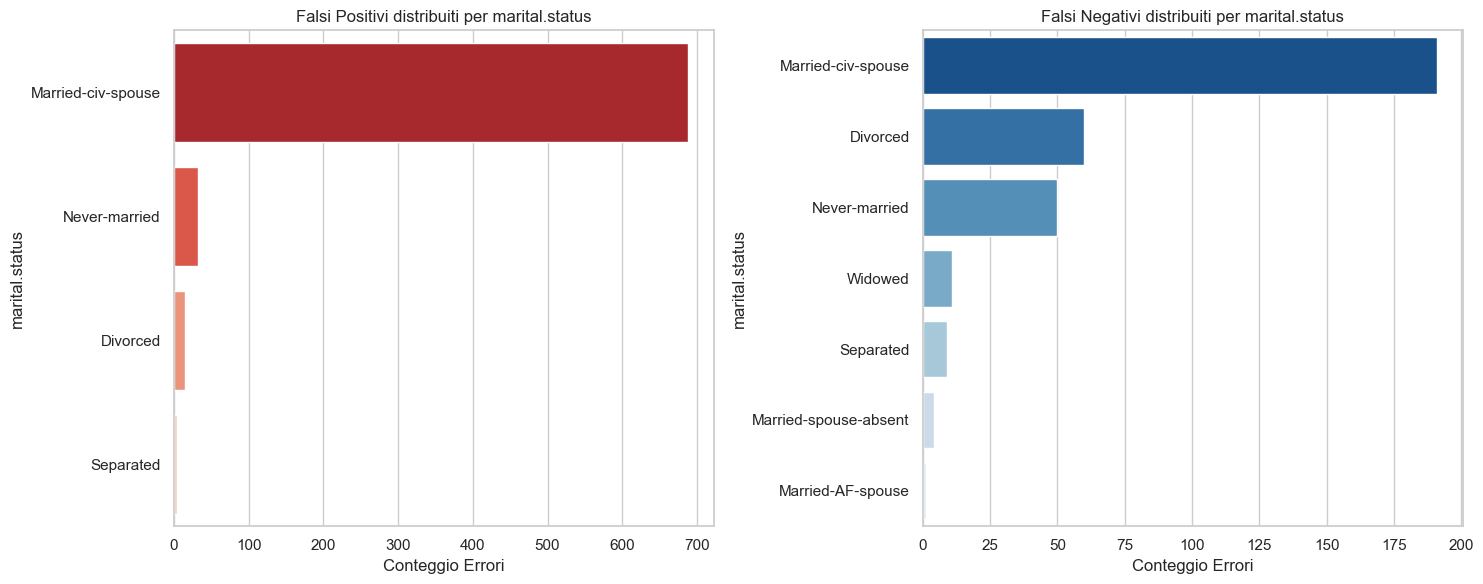

In [ ]:



# 2. Uniamo X_test, i valori reali (y_test) e le predizioni in un unico DataFrame
# Assicurati che y_test sia un array o una serie con gli stessi indici di X_test
results_df = X_test.copy()
results_df['Valore_Reale'] = y_test.values if isinstance(y_test, pd.Series) else y_test
results_df['Predizione'] = y_pred

# 3. Isoliamo gli errori
# Falsi Positivi: Predizione = 1 (Classe 1), ma Reale = 0 (Classe 0)
falsi_positivi = results_df[(results_df['Predizione'] == 1) & (results_df['Valore_Reale'] == 0)]

# Falsi Negativi: Predizione = 0 (Classe 0), ma Reale = 1 (Classe 1)
falsi_negativi = results_df[(results_df['Predizione'] == 0) & (results_df['Valore_Reale'] == 1)]

print(f"Numero totale di Falsi Positivi: {len(falsi_positivi)}")
print(f"Numero totale di Falsi Negativi: {len(falsi_negativi)}")

# 4. Analizziamo dove il modello si confonde (Esempio su una colonna a scelta)
# Sostituisci 'marital.status' con una variabile che ti interessa (es. 'age' o 'education')
feature_to_analyze = 'marital.status'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grafico Falsi Positivi
sns.countplot(data=falsi_positivi, y=feature_to_analyze, ax=axes[0], palette="Reds_r", order=falsi_positivi[feature_to_analyze].value_counts().index)
axes[0].set_title(f"Falsi Positivi distribuiti per {feature_to_analyze}")
axes[0].set_xlabel("Conteggio Errori")

# Grafico Falsi Negativi
sns.countplot(data=falsi_negativi, y=feature_to_analyze, ax=axes[1], palette="Blues_r", order=falsi_negativi[feature_to_analyze].value_counts().index)
axes[1].set_title(f"Falsi Negativi distribuiti per {feature_to_analyze}")
axes[1].set_xlabel("Conteggio Errori")

plt.tight_layout()
plt.show()

Gemini ha detto
Ottimo lavoro! I grafici sono chiarissimi e la cosa più bella è che ci raccontano una storia perfettamente in linea con quello che avevamo scoperto con i grafici precedenti. Ecco come possiamo leggere e presentare questi errori:

1. Falsi Positivi (Il modello è "troppo ottimista")
Cosa vediamo: La barra rossa schizza alle stelle per la categoria Married-civ-spouse.

Perché succede: Ti ricordi il grafico PDP di prima? Il modello aveva imparato una regola fortissima: "Se è sposato, ha un'alta probabilità di guadagnare >50K". Questo grafico ci dimostra che il modello è diventato quasi dipendente da questa regola. Appena vede una persona sposata, si fa prendere dall'entusiasmo e le assegna un reddito alto, finendo per sovrastimare molte persone sposate che in realtà guadagnano meno di 50.000$. È vittima del suo stesso bias.

2. Falsi Negativi (Il modello è "troppo pessimista")
Cosa vediamo: Anche qui la categoria degli sposati è alta (semplicemente perché sono la maggioranza assoluta nel dataset), ma guarda attentamente le barre di Never-married (Single) e Divorced. Rispetto al grafico rosso, qui sono molto più visibili.

Perché succede: Il modello ragiona al contrario: "Non sei sposato? Allora guadagnerai sicuramente poco". Così facendo, taglia fuori e sbaglia a prevedere tutti quei single o divorziati in carriera che invece superano abbondantemente i 50K.

## XGBoost
È l'evoluzione degli alberi. Invece di allenare 100 alberi separati (come Random Forest), XGBoost ne allena uno, guarda dove ha sbagliato, e allena il secondo per correggere quegli errori specifici.

Perché farlo: È quasi sempre il modello vincitore su dati tabellari (come il censimento).

Cosa aspettarsi: Una curva ROC ancora più "aderente" all'angolo in alto a sinistra e un'area (AUC) che potrebbe salire a 0.92-0.94.

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Creiamo la pipeline con XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

# Definiamo i parametri per il Tuning (fondamentale per XGBoost)
param_grid_xgb = {
    'classifier__n_estimators': [100],
    'classifier__learning_rate': [0.1], # La velocità di correzione degli errori
    'classifier__max_depth': [3, 6],      # Profondità degli alberi
    'classifier__subsample': [0.8, 1.0]       # % di dati usati per ogni albero
}

grid_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print(f"Miglior AUC con XGBoost: {grid_xgb.best_score_:.4f}")

Miglior AUC con XGBoost: 0.9290


In [ ]:
grid_xgb.best_params_

{'classifier__learning_rate': 0.1,
 'classifier__max_depth': 6,
 'classifier__n_estimators': 100,
 'classifier__subsample': 1.0}

### Log loss xgboost

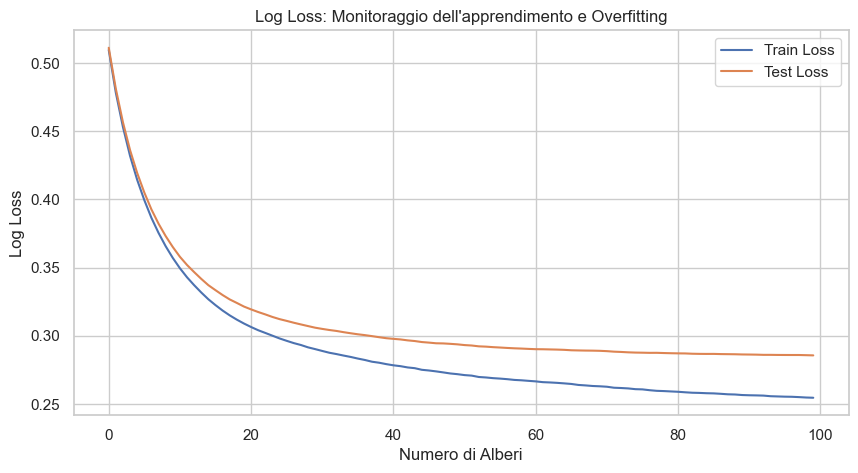

In [ ]:
# 1. Estraiamo i migliori parametri e il preprocessor
best_params = grid_xgb.best_params_
# Rimuoviamo il prefisso 'classifier__' dai nomi dei parametri per passatli a XGB
xgb_params = {k.replace('classifier__', ''): v for k, v in best_params.items()}

# 2. Trasformiamo i dati una volta sola per velocizzare
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# 3. Alleniamo il modello finale monitorando l'errore
final_xgb = XGBClassifier(**xgb_params, eval_metric='logloss', random_state=42)
final_xgb.fit(X_train_proc, y_train, 
              eval_set=[(X_train_proc, y_train), (X_test_proc, y_test)], 
              verbose=False)

# 4. Grafico della Log Loss
results = final_xgb.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['logloss'], label='Train Loss')
plt.plot(results['validation_1']['logloss'], label='Test Loss')
plt.title('Log Loss: Monitoraggio dell\'apprendimento e Overfitting')
plt.xlabel('Numero di Alberi')
plt.ylabel('Log Loss')
plt.legend()
plt.show()

Entrambe le curve scendono rapidamente all'inizio, poi si appiattiscono. Questo è normale e positivo — il modello impara velocemente nei primi alberi, poi i miglioramenti diventano marginali.

Il punto critico: il divario tra le due curve
Train Loss (blu)  → 0.256  (continua a scendere)
Test Loss (arancio) → 0.288  (si ferma prima)
C'è un gap crescente tra train e test, specialmente dopo i 40 alberi. Questo è un segnale di overfitting lieve — il modello inizia a memorizzare il training set invece di generalizzare.

È preoccupante?
SituazioneGiudizioGap piccolo (0.03)Lieve, non graveTest loss si stabilizzaBuon segnoTrain loss continua a scendereConferma overfitting leggero
In questo caso non è allarmante, ma indica che forse 100 alberi sono troppi. Il test loss smette di migliorare intorno ai 60-70 alberi.

Cosa fare
Puoi aggiungere early_stopping per fermare il training automaticamente quando il test loss non migliora più

### SHAP xgboost

In [ ]:
import shap

# 1. estrai il modello dalla pipeline
xgb_model = grid_xgb.best_estimator_.named_steps['classifier']

# 2. trasforma X_test con il preprocessor
X_test_transformed = grid_xgb.best_estimator_.\
                     named_steps['preprocessor']\
                     .transform(X_test)

# 3. crea l'explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

### Grafico 1 — Importanza globale (bar chart)

Risponde a: **"quali feature contano di più in media?"**
```
Feature 29 → 1.1   ← la più importante in assoluto
Feature 0  → 0.68
Feature 2  → 0.47
...
Feature 45 → ~0.02  ← quasi irrilevante
```

È la media del valore assoluto SHAP su tutto il test set. Non dice la direzione, solo il **peso**.


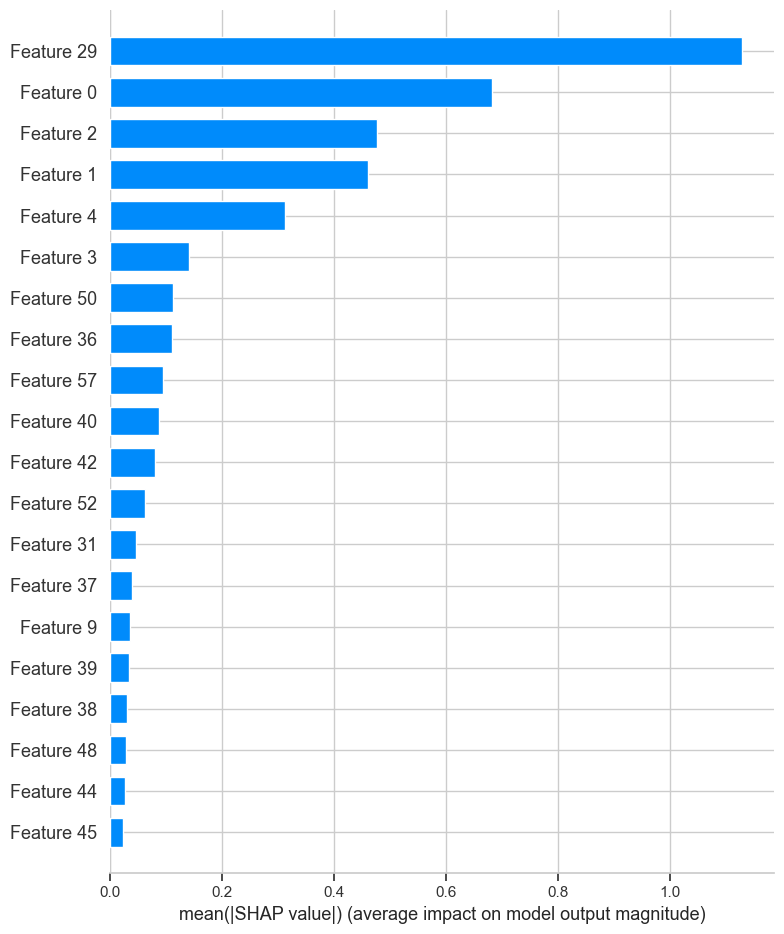

In [ ]:
shap.summary_plot(shap_values, X_test_transformed, plot_type="bar")

In [ ]:
# se usi get_feature_names_out dal preprocessor
feature_names = grid_xgb.best_estimator_\
                .named_steps['preprocessor']\
                .get_feature_names_out()

# print(feature_names[29])   # ti dice il nome reale
# print(list(enumerate(feature_names)))  # lista completa indice → nome

### Grafico 2 — Beeswarm plot

Risponde a: **"in che direzione e con che intensità ogni feature influenza la predizione?"**

Ogni punto è **una riga del tuo dataset**. Il colore dovrebbe essere rosso/blu (alto/basso valore della feature) ma nel tuo grafico appare grigio — probabilmente un problema di rendering.

Cosa noti:
- **Feature 2** ha punti che arrivano fino a +8 → casi estremi che spingono molto verso classe 1
- **Feature 29** ha punti sia a sinistra che a destra → può spingere in entrambe le direzioni
- **Feature 3** ha una distribuzione molto larga → comportamento variabile

Feature 2: num__capital.gain (Guadagni in conto capitale)

Feature 3: num__capital.loss (Perdite in conto capitale)

Feature 29: cat__marital.status_Married-civ-spouse (Stato civile: Sposato/a con coniuge civile)

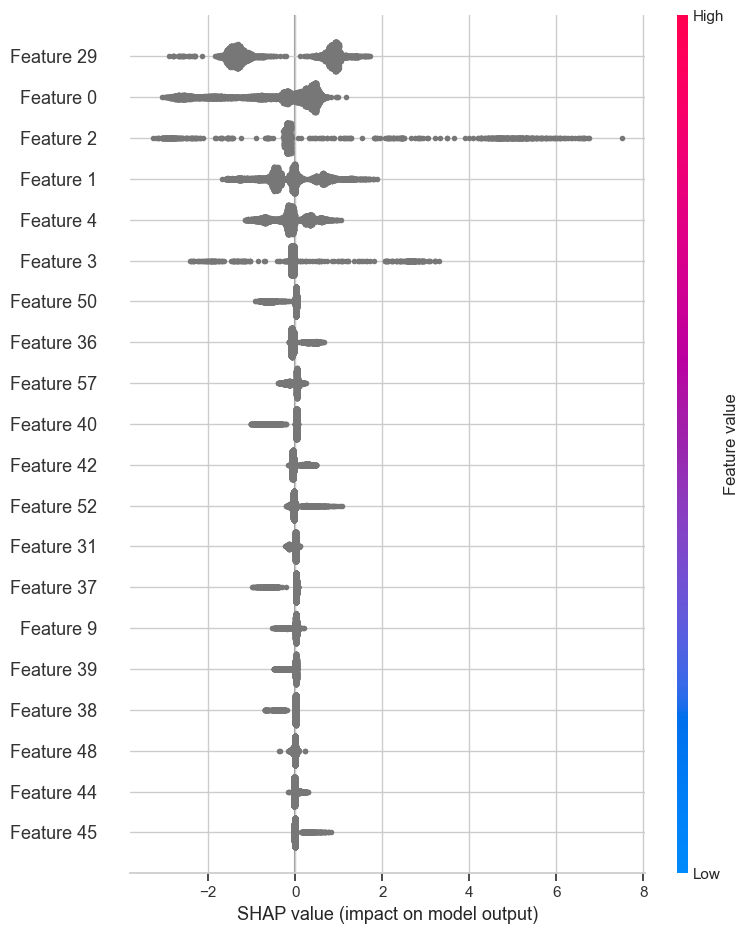

In [ ]:
shap.summary_plot(shap_values, X_test_transformed)

### Grafico 3 — Waterfall plot (singola predizione)

Risponde a: **"perché il modello ha dato questo risultato per questa persona specifica?"**
```
E[f(X)] = -1.188   ← punto di partenza (media del modello su tutti)
f(x)    = -1.979   ← predizione finale per questa persona

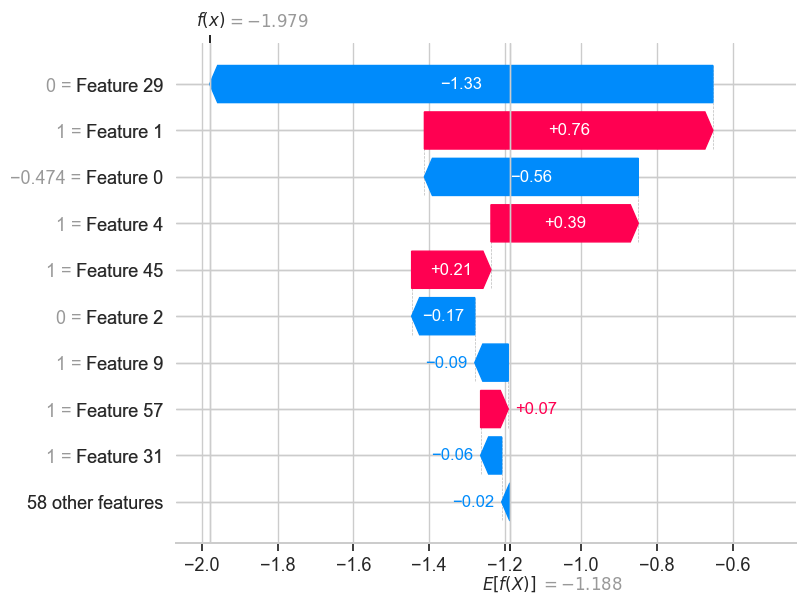

In [ ]:
shap.waterfall_plot(explainer(X_test_transformed)[0])

<!-- | Feature | Valore | SHAP | Effetto |
| :--- | :--- | :--- | :--- |
| **Feature 2** | 90 | -1.33 | spinge forte verso classe 0 |
| **Feature 1** | 1 | +0.76 | spinge verso classe 1 |
| **Feature 0** | -0.474 | -0.56 | spinge verso classe 0 |
| **Feature 4** | 1 | +0.39 | spinge verso classe 1 |

La predizione finale -1.979 è il risultato di tutte queste spinte sommate al punto di partenza. Essendo negativa, il modello classifica questa persona come classe 0. -->

## Cluster

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

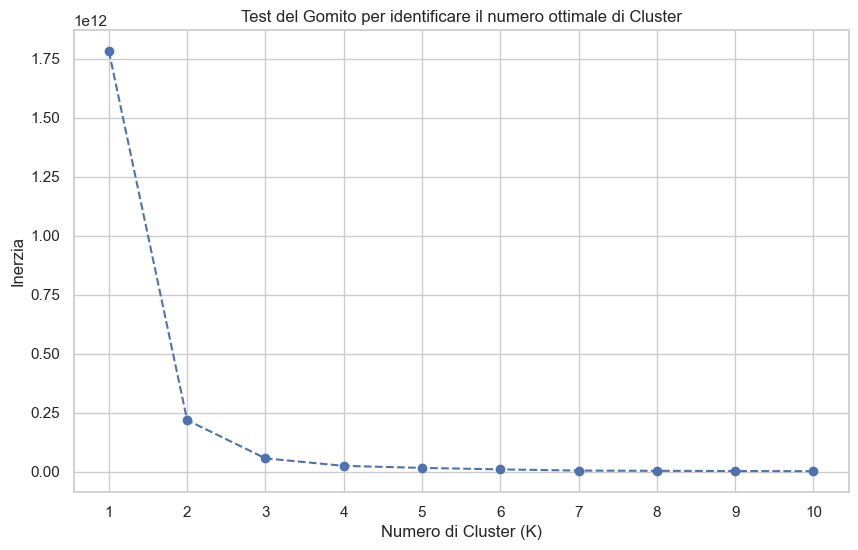

In [ ]:
# 1. Usiamo il preprocessor per avere i dati pronti (scalati e codificati)
X_preprocessed = preprocessor.fit_transform(X)

inerzia = []
K_range = range(1, 11) # Proviamo da 1 a 10 cluster

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_preprocessed)
    inerzia.append(km.inertia_)

# 2. Plot del grafico
plt.figure(figsize=(10, 6))
plt.plot(K_range, inerzia, marker='o', linestyle='--')
plt.xlabel('Numero di Cluster (K)')
plt.ylabel('Inerzia')
plt.title('Test del Gomito per identificare il numero ottimale di Cluster')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [ ]:
# Eseguiamo il K-Means finale con K scelto (es. 2)
kmeans_final = KMeans(n_clusters=3, random_state=42)
clusters = kmeans_final.fit_predict(X_preprocessed)

# Aggiungiamo i cluster al DataFrame originale per confrontare
df_1['cluster'] = clusters

# Vediamo come si distribuisce il reddito nei cluster
print(pd.crosstab(df_1['cluster'], df_1['is_high_income']))

is_high_income      0     1
cluster                    
0               24652  6447
1                   0   159
2                  68  1235


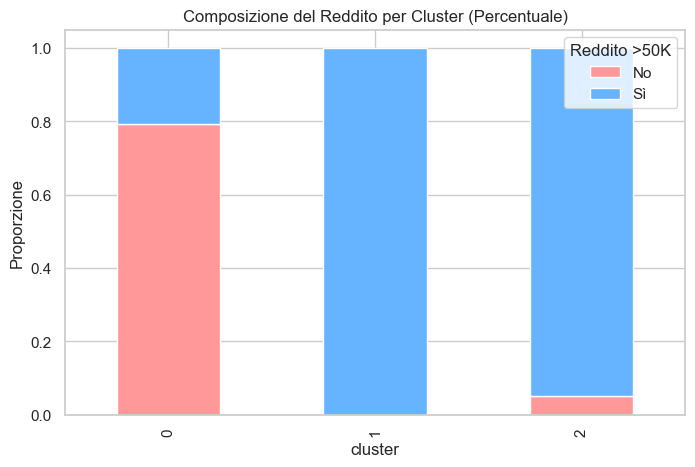

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creiamo la tabella percentuale
ct_pct = pd.crosstab(df_1['cluster'], df_1['is_high_income'], normalize='index')

# Grafico
ct_pct.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#ff9999', '#66b3ff'])
plt.title("Composizione del Reddito per Cluster (Percentuale)")
plt.ylabel("Proporzione")
plt.legend(title="Reddito >50K", labels=["No", "Sì"])
plt.show()

## Deep Learning 

In [ ]:
from sklearn.neural_network import MLPClassifier

# Definiamo la Pipeline per il Deep Learning
mlp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(100, 50), 
        max_iter=500, 
        activation='relu', 
        solver='adam', 
        random_state=42,
        early_stopping=True # Evita l'overfitting fermandosi quando l'errore non scende più
    ))
])

# Training
mlp_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## ROC curve final comparison

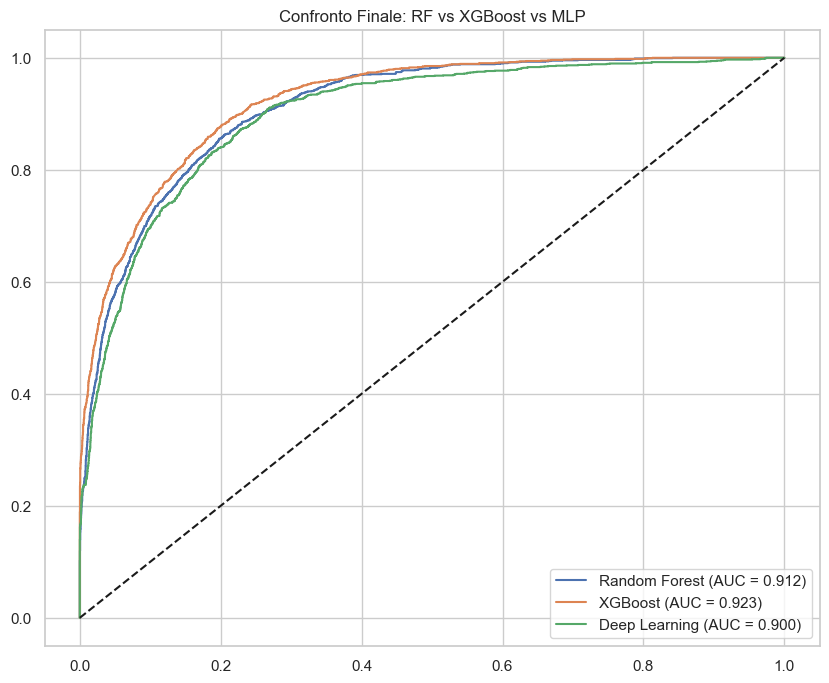

In [ ]:
from sklearn.metrics import roc_curve, auc

# Calcoliamo le probabilità per tutti e tre
y_prob_rf = best_model.predict_proba(X_test)[:, 1]
y_prob_xgb = grid_xgb.predict_proba(X_test)[:, 1]
y_prob_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]

# Funzione per plottare tutto insieme
plt.figure(figsize=(10, 8))
for name, prob in [("Random Forest", y_prob_rf), ("XGBoost", y_prob_xgb), ("Deep Learning", y_prob_mlp)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("Confronto Finale: RF vs XGBoost vs MLP")
plt.legend()
plt.show()